## Desarrollo tarea HW Sesión 2

Felipe López Vergara

Descarga de librerías necesarias

In [2]:
# Librerías necesarias — no modifique esta celda
from matplotlib import pyplot as plt
from scipy.stats import f_oneway, mannwhitneyu, kruskal, levene, bartlett
from scipy.optimize import minimize
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import seaborn as sns
import yfinance as yf
import pandas as pd
import numpy as np

sns.set_style("dark")
np.random.seed(20260607)

### Parte I: Transformación de Datos Financieros (25 puntos)

Trabajará con el siguiente portafolio de activos del sector tecnológico y financiero para el período 2021-01-01 al 2024-12-31:

Ticker	Empresa
AAPL	Apple Inc.
AMZN	Amazon.com Inc.
JPM	    JPMorgan Chase & Co.
GS	    Goldman Sachs Group Inc.
TSLA	Tesla Inc.

Pregunta 1.1 — Retornos Simples y Logarítmicos (8 puntos)

a) Descargue los precios de cierre del portafolio definido anteriormente.

In [26]:
# Extracción de datos utilizando yfinance
def descargar_datos_yf(tickers, start, end):
    data = yf.download(tickers, start=periodo[0], end=periodo[1], progress=False)
    return data

tickers = ['AAPL', 'AMZN','JPM', 'GS', 'TSLA']
periodo = ('2021-01-01', '2024-12-31')

df = descargar_datos_yf(tickers, periodo[0], periodo[1])['Close']
df.head()

Ticker,AAPL,AMZN,GS,JPM,TSLA
2021-01-04,125.740852,159.331497,233.060928,109.491554,243.256668
2021-01-05,127.295479,160.925507,238.276215,110.087341,245.036667
2021-01-06,123.010506,156.919006,251.134125,115.256584,251.993332
2021-01-07,127.208023,158.108002,256.498932,119.041512,272.013336
2021-01-08,128.306015,159.134995,255.118195,119.172966,293.339996


b) Calcule los retornos diarios simples y logarítmicos para cada activo.

In [27]:
# Cálculos de retornos del DataFrame
retornos_simple = df.pct_change().dropna()
retornos_log = np.log(df / df.shift(1))

retornos_simple.head()



Ticker,AAPL,AMZN,GS,JPM,TSLA
2021-01-05,0.012364,0.010004,0.022377,0.005441,0.007317
2021-01-06,-0.033662,-0.024897,0.053962,0.046956,0.028390
2021-01-07,0.034123,0.007577,0.021362,0.032839,0.079447
2021-01-08,0.008631,0.006496,-0.005383,0.001104,0.078403
2021-01-11,-0.023249,-0.021519,0.012927,0.014924,-0.078214


c) Para el activo TSLA, grafique en un mismo panel de dos subplots: la serie de precios y la serie de retornos logarítmicos.

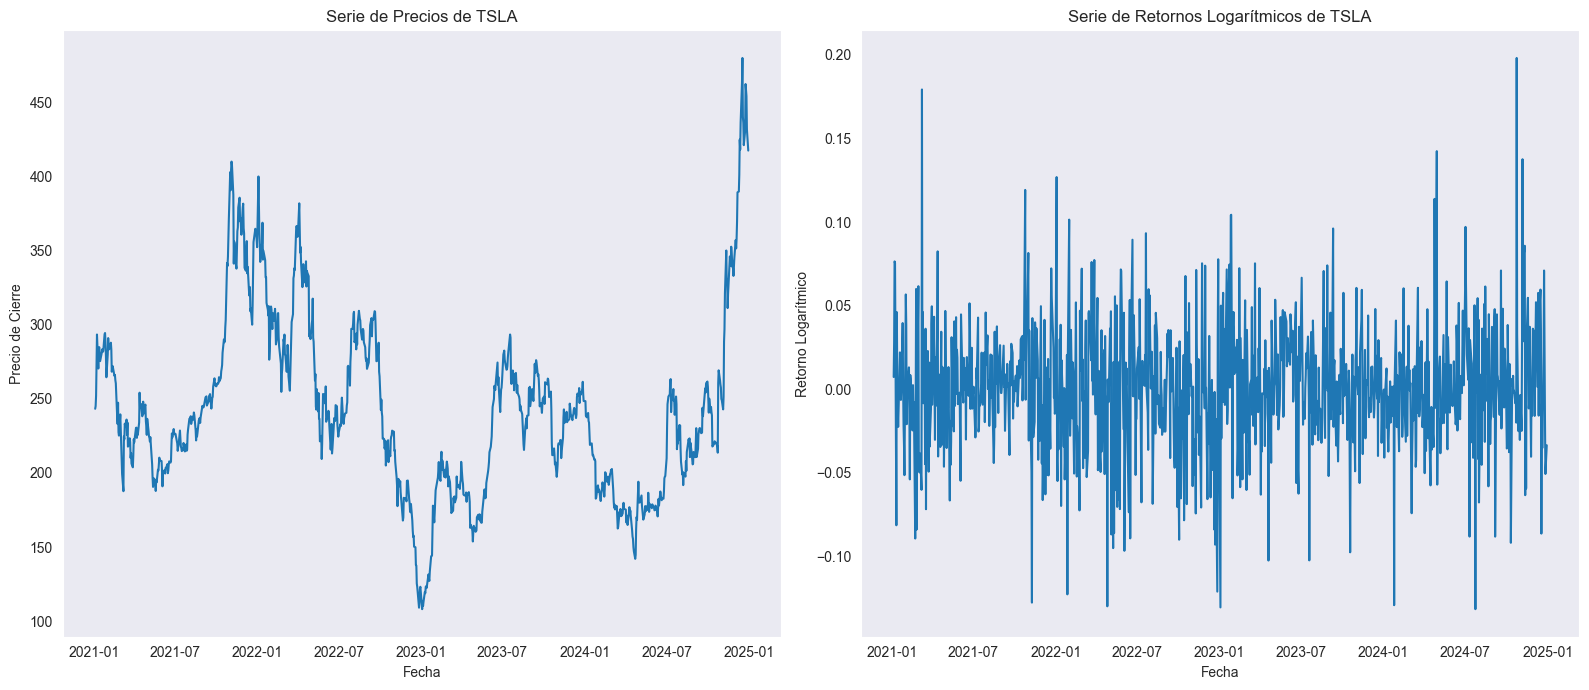

In [28]:
# Serie de Precios y Retornos logarítmicos de Tesla

fig, axes = plt.subplots(1, 2, figsize = (16, 7))

sns.lineplot(data = df['TSLA'], ax = axes[0])
axes[0].set_title('Serie de Precios de TSLA')
axes[0].set_xlabel('Fecha')
axes[0].set_ylabel('Precio de Cierre')  

sns.lineplot(data = retornos_log['TSLA'], ax = axes[1])
axes[1].set_title('Serie de Retornos Logarítmicos de TSLA')
axes[1].set_xlabel('Fecha')
axes[1].set_ylabel('Retorno Logarítmico')

plt.tight_layout() 
plt.show()


d) ¿Qué diferencias observa entre los retornos simples y logarítmicos? ¿En qué escenarios es más conveniente usar retornos logarítmicos? Justifique su respuesta.

### Pregunta 1.2 — Retornos Multi-Período (9 puntos)

Para el activo **JPM**:

a) Calcule los retornos **diarios, semanales y mensuales** (simples y logarítmicos).

In [6]:
#Retonro diario de JPM
ret_diario_simple_jpm = df['JPM'].pct_change().dropna()
ret_diario_log_jpm = np.log(df['JPM'] / df['JPM'].shift(1))

#Retonro semanal de JPM
precios_semanal_jpm = df['JPM'].resample('W').last()
ret_semanal_simple_jpm = precios_semanal_jpm.pct_change().dropna()
ret_semanal_log_jpm = np.log(precios_semanal_jpm / precios_semanal_jpm.shift(1))

#Retonro mensual de JPM
precios_mensual_jpm = df['JPM'].resample('ME').last()
ret_mensual_simple_jpm = precios_mensual_jpm.pct_change().dropna()
ret_mensual_log_jpm = np.log(precios_mensual_jpm / precios_mensual_jpm.shift(1))


b) Calcule el retorno acumulado a rolling 20 días usando retornos logarítmicos (recuerde la propiedad de aditividad: $r_t(k) =\\suma_{i=0}^{k-1} r_{ti}$).


In [7]:
#Retorno a 20 días de JPM

rolling_20d_log_jpm = np.log(df['JPM'] / df['JPM'].shift(20))

c) Visualice en un solo gráfico el retorno logarítmico diario y el retorno rolling de 20 días para JPM.

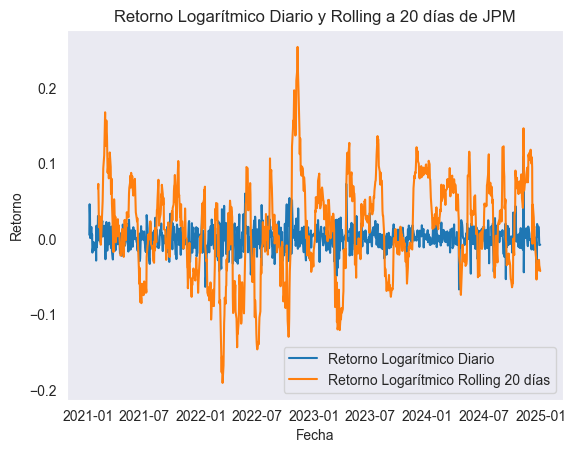

In [8]:
#Gráficos de Retornos logarítmico diario y retorno rolling a 20 días de JPM

sns.lineplot(data = ret_diario_log_jpm, label = 'Retorno Logarítmico Diario')
sns.lineplot(data = rolling_20d_log_jpm, label = 'Retorno Logarítmico Rolling 20 días')
plt.title('Retorno Logarítmico Diario y Rolling a 20 días de JPM')
plt.xlabel('Fecha')
plt.ylabel('Retorno')
plt.legend()
plt.show()


d) Calcule la media, desviación estándar, asimetría (skewness) y curtosis para los retornos diarios de cada frecuencia (diario, semanal, mensual). Presente los resultados en un DataFrame resumen.

In [9]:
# Función para calcular estadísticas

def calcular_estadisticas(retornos):
    return pd.Series({
        'Media': retornos.mean(),
        'Mediana': retornos.median(),
        'Desviación Estándar': retornos.std(),
        'Curtosis': retornos.kurtosis(),
        'Asimetría': retornos.skew()
    })

# DataFrame resumen
estadisticas_jpm = pd.DataFrame({
    'Retorno Diario Simple': calcular_estadisticas(ret_diario_simple_jpm),
    'Retorno Diario Logarítmico': calcular_estadisticas(ret_diario_log_jpm),
    'Retorno Semanal Simple': calcular_estadisticas(ret_semanal_simple_jpm),
    'Retorno Semanal Logarítmico': calcular_estadisticas(ret_semanal_log_jpm),
    'Retorno Mensual Simple': calcular_estadisticas(ret_mensual_simple_jpm),
    'Retorno Mensual Logarítmico': calcular_estadisticas(ret_mensual_log_jpm)
})

print(estadisticas_jpm)

                     Retorno Diario Simple  Retorno Diario Logarítmico  \
Media                             0.000865                    0.000749   
Mediana                           0.001104                    0.001104   
Desviación Estándar               0.015214                    0.015174   
Curtosis                          4.957097                    4.402300   
Asimetría                         0.335349                    0.186649   

                     Retorno Semanal Simple  Retorno Semanal Logarítmico  \
Media                              0.003779                     0.003205   
Mediana                            0.006998                     0.006974   
Desviación Estándar                0.033809                     0.033794   
Curtosis                           0.704800                     0.662756   
Asimetría                         -0.095360                    -0.227740   

                     Retorno Mensual Simple  Retorno Mensual Logarítmico  
Media                  

### Pregunta 1.3 — Estandarización y Normalización (8 puntos)

a) Tome los retornos diarios simples del portafolio completo (5 activos). Aplique estandarización (Standard Scaler) y normalización (Min-Max Scaler) a cada serie de retornos.

In [24]:
# Estandarización (Standar Scaling)
scaler = StandardScaler()
X_scaled_standard = scaler.fit_transform(retornos_simple)

# Normalización (Min-Max Scaling)
scaler = MinMaxScaler()
X_scaled_minmax = scaler.fit_transform(retornos_simple)

b) Para los activos AAPL y TSLA, grafique en un panel de 3 columnas (original, estandarizado, normalizado) los histogramas de retornos.

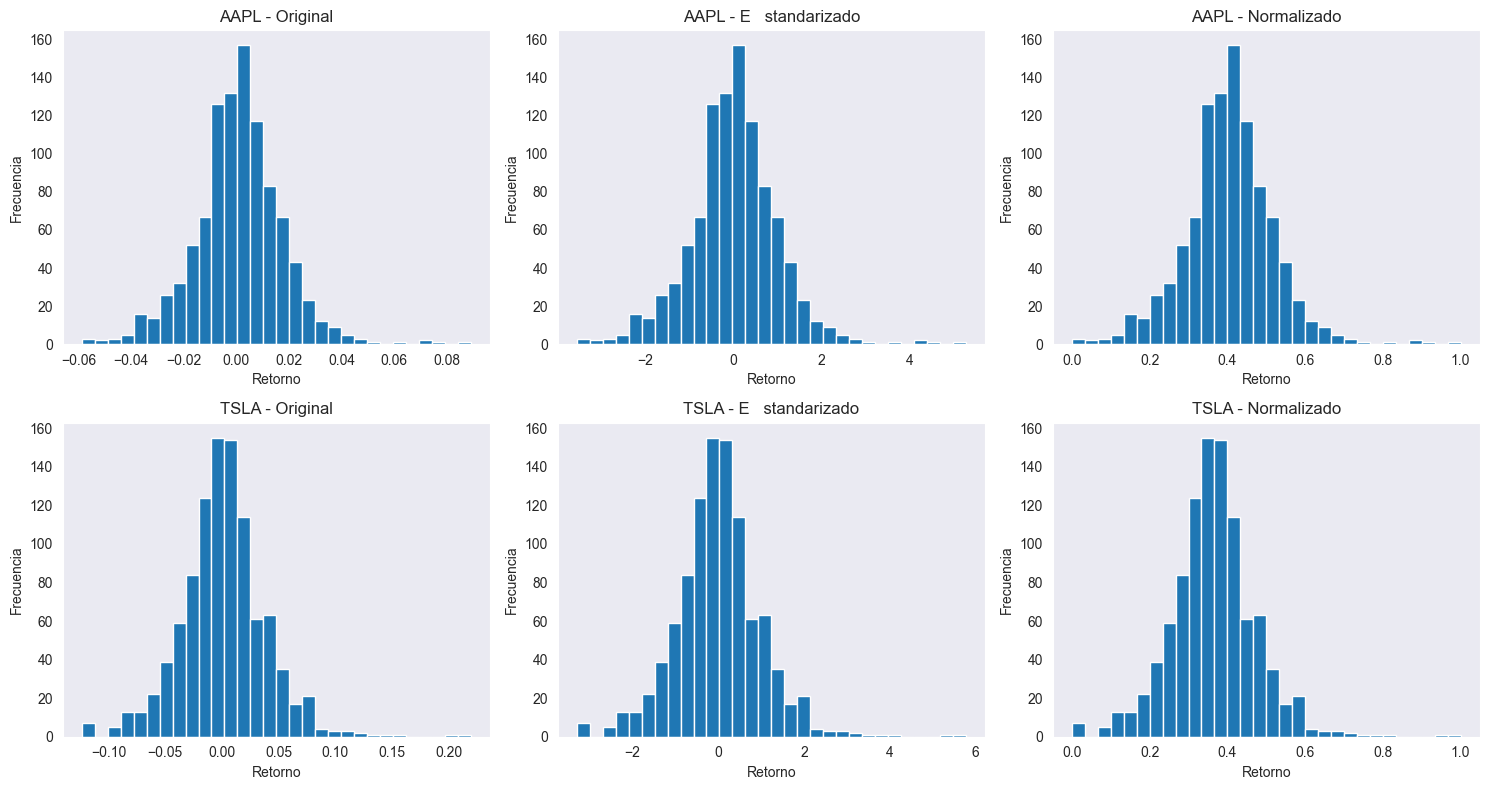

In [25]:
# Gráficos Retornos diarios, normalizados y estandarizados de AAPL y TSLA

# Seleccionar activos
acciones = retornos_simple[['AAPL', 'TSLA']].dropna()

# Estandarización 
scaler_std = StandardScaler()
df_std = pd.DataFrame(
    scaler_std.fit_transform(acciones),
    columns=acciones.columns,
    index=acciones.index
)

# Normalización 
scaler_norm = MinMaxScaler()
df_norm = pd.DataFrame(
    scaler_norm.fit_transform(acciones),
    columns=acciones.columns,
    index=acciones.index      
)

# Crear gráficos de histogramas para cada acción y cada tipo de retorno
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

activos = ['AAPL', 'TSLA']
datasets = [acciones, df_std, df_norm]
titulos = ['Original', 'E   standarizado', 'Normalizado']

for i, activo in enumerate(activos):
    for j, (data, titulo) in enumerate(zip(datasets, titulos)):
        axes[i, j].hist(data[activo], bins=30)
        axes[i, j].set_title(f'{activo} - {titulo}')
        axes[i, j].set_xlabel('Retorno')
        axes[i, j].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

c) ¿Cuál de las dos transformaciones es más adecuada para comparar la volatilidad relativa entre los activos del portafolio? Justifique.

## Parte II: Análisis de Relaciones y Estructura de Riesgo (25 puntos)

### Pregunta 2.1 — Matrices de Correlación (10 puntos)

a) Calcule las matrices de correlación de Pearson, Spearman y Kendall para los 5 activos.

In [33]:
# Correlación de Pearson
retornos_simple.corr(method='pearson')

Ticker,AAPL,AMZN,GS,JPM,TSLA
Ticker,,,,,
AAPL,1.000000,0.562225,0.332048,0.294701,0.492028
AMZN,0.562225,1.000000,0.359424,0.295769,0.427575
GS,0.332048,0.359424,1.000000,0.763537,0.287263
JPM,0.294701,0.295769,0.763537,1.000000,0.261379
TSLA,0.492028,0.427575,0.287263,0.261379,1.000000


In [34]:
# Correlación de Spearman
retornos_simple.corr(method='spearman')

Ticker,AAPL,AMZN,GS,JPM,TSLA
Ticker,,,,,
AAPL,1.000000,0.595979,0.332786,0.292708,0.503416
AMZN,0.595979,1.000000,0.331142,0.272555,0.458631
GS,0.332786,0.331142,1.000000,0.745480,0.302986
JPM,0.292708,0.272555,0.745480,1.000000,0.275199
TSLA,0.503416,0.458631,0.302986,0.275199,1.000000


In [35]:
# Correlación de Kendall
retornos_simple.corr(method='kendall')

Ticker,AAPL,AMZN,GS,JPM,TSLA
Ticker,,,,,
AAPL,1.000000,0.431524,0.231000,0.204107,0.352090
AMZN,0.431524,1.000000,0.228481,0.189090,0.320922
GS,0.231000,0.228481,1.000000,0.562387,0.207607
JPM,0.204107,0.189090,0.562387,1.000000,0.187280
TSLA,0.352090,0.320922,0.207607,0.187280,1.000000


b) Visualice las tres matrices en un panel de 3 heatmaps con anotaciones numéricas.

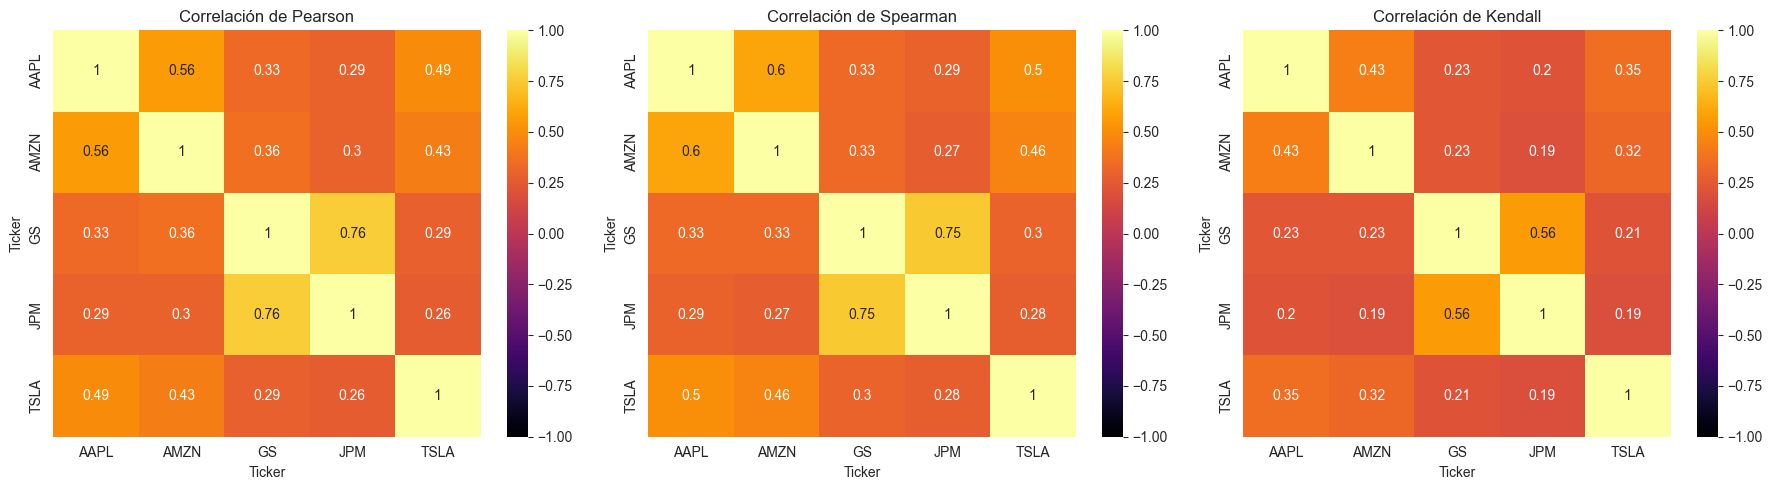

In [36]:
#Cración de mapas heatmap para cada tipo de correlación
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(retornos_simple.corr(method='pearson'), annot=True, cmap='inferno', ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('Correlación de Pearson')

sns.heatmap(retornos_simple.corr(method='spearman'), annot=True, cmap='inferno', ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title('Correlación de Spearman')

sns.heatmap(retornos_simple.corr(method='kendall'), annot=True, cmap='inferno', ax=axes[2], vmin=-1, vmax=1)
axes[2].set_title('Correlación de Kendall')

plt.tight_layout()
plt.show()

c) Identifique el par de activos con mayor y menor correlación de Pearson.

Los

Compare los resultados entre Pearson y Spearman. ¿Existen diferencias relevantes? ¿A qué se pueden deber estas diferencias en el contexto de retornos financieros?

Al 

### Pregunta 2.2 — Matriz de Covarianza (8 puntos)

a) Calcule la matriz de varianzas y covarianzas para los retornos mensuales del portafolio.

In [40]:
#Matriz de covarianza de los retornos mensuales simples

retorno_mensual_simple = df.resample('ME').last().pct_change().dropna()
retorno_mensual_covarianza = retorno_mensual_simple.cov()

retorno_mensual_covarianza

Ticker,AAPL,AMZN,GS,JPM,TSLA
Ticker,,,,,
AAPL,0.005452,0.004582,0.002046,0.001129,0.007980
AMZN,0.004582,0.008780,0.002156,0.001260,0.010944
GS,0.002046,0.002156,0.006626,0.005119,0.003233
JPM,0.001129,0.001260,0.005119,0.005446,0.001130
TSLA,0.007980,0.010944,0.003233,0.001130,0.032387


b) Verifique que es semidefinida positiva calculando sus valores propios (eigenvalues) e imprimiéndolos. ¿Qué condición deben cumplir?

In [41]:
# Matriz de correlación o covarianza
eigenvalues = np.linalg.eigvals(retorno_mensual_covarianza)

print("Valores propios:")
print(eigenvalues)

Valores propios:
[0.03984996 0.01097119 0.00484331 0.00221905 0.00080758]


Deben cumplir la condición de que todos sus valores propios son mayores o iguales a cero.

c) A partir de $\\Sigma$ , calcule la volatilidad anualizada de cada activo. Recuerde que $\\sigma_{\\texto{anual}} =\\sigma_{\\texto{mensual}}\\veces\\sqrt{12}$.

In [42]:
# Volatilidades mensuales
vol_mensual = np.sqrt(np.diag(retorno_mensual_covarianza))

# Volatilidades anualizadas
vol_anual = vol_mensual * np.sqrt(12)

# Mostrar resultados
volatilidades = pd.DataFrame({
    'Volatilidad Mensual': vol_mensual,
    'Volatilidad Anualizada': vol_anual
}, index=retorno_mensual_covarianza.index)

print(volatilidades)

        Volatilidad Mensual  Volatilidad Anualizada
Ticker                                             
AAPL               0.073837                0.255780
AMZN               0.093700                0.324587
GS                 0.081401                0.281983
JPM                0.073799                0.255649
TSLA               0.179963                0.623412


d) Según la covarianza, ¿qué par de activos ofrece mejor diversificación? Justifique.

Según 